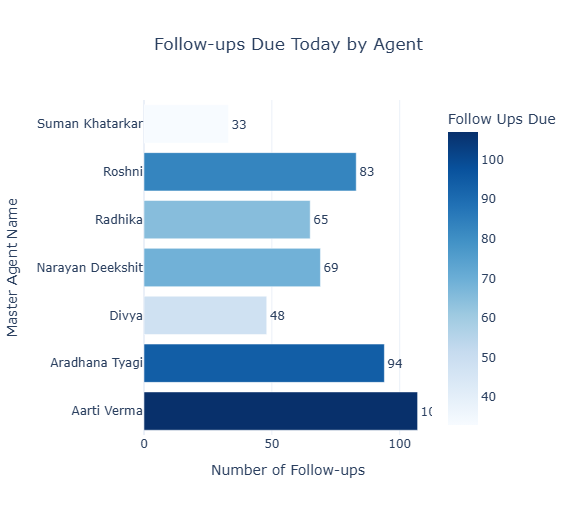

In [ ]:
import pandas as pd
import plotly.express as px
sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

df["Follow Up Date"] = pd.to_datetime(df["Follow Up Date"], dayfirst=True)



today = pd.Timestamp('2026-07-30')


followups_today = df[df["Follow Up Date"] == today]


agent_followups = (
    followups_today.groupby("Master Agent Name")
    .size()
    .reset_index(name="Follow Ups Due")
)


fig = px.bar(
    agent_followups,
    x="Follow Ups Due",
    y="Master Agent Name",
    orientation="h",
    color="Follow Ups Due",
    color_continuous_scale="Blues",
    text="Follow Ups Due",
    title="Follow-ups Due Today by Agent"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    xaxis_title="Number of Follow-ups",
    yaxis_title="Master Agent Name",
    title_x=0.5
)

fig.show()